# Sesi 09 - Pivot Tabel & Agregasi Lanjutan

Pivot tabel adalah cara merangkum data besar menjadi sesuati yang mudah dipahami dan dibaca
Di Excel mungkin kita sudah mengenalnya, nah di Python kita juga bisa melakukannya
Bahkan lebih powerful!

## 1. Load Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("samplesuperstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

print("Shape: ", df.shape)
df.head(3)

Shape:  (10194, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,US-2023-103800,2023-01-03,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023
1,2,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023
2,3,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023


## 2. Pivot Tabel Dasar

In [9]:
# Pivot rata-rata Sales per category & region
pivot1 = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

print(pivot1)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   164537.6518       168216.709  170416.312
East      212231.6960       211658.401  267938.071
South     117298.6840       125651.313  148771.908
West      260679.7295       226366.891  252766.988


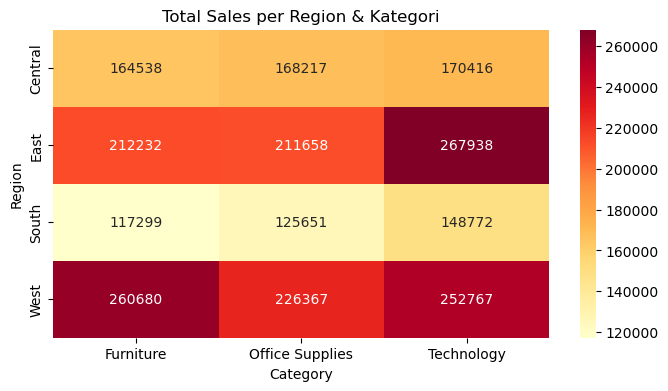

In [21]:
# Visualisasi pivot sebagai heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Total Sales per Region & Kategori")
plt.show()

## 3. Multi Level Agregasi

In [23]:
#Agregasi banyak fungsi sekaligus
ringkasan = df.groupby(["Region", "Category"]).agg(
    total_sales = ("Sales", "sum"),
    total_profit = ("Profit", "sum"),
    jumlah_order = ("Order ID", "count"),
    rata_diskon = ("Discount", "mean")
).reset_index()

#Tambah kolom margin profit
ringkasan["margin_%"] = (ringkasan["total_profit"]/ringkasan["jumlah_order"] * 100).round(1)

print(ringkasan)

     Region         Category  total_sales  total_profit  jumlah_order  \
0   Central        Furniture  164537.6518    -2802.2067           485   
1   Central  Office Supplies  168216.7090     8970.0817          1430   
2   Central       Technology  170416.3120    33697.4320           420   
3      East        Furniture  212231.6960     3444.7448           649   
4      East  Office Supplies  211658.4010    42996.7397          1792   
5      East       Technology  267938.0710    48441.7758           545   
6     South        Furniture  117298.6840     6771.2061           332   
7     South  Office Supplies  125651.3130    19986.3928           995   
8     South       Technology  148771.9080    19991.8314           293   
9      West        Furniture  260679.7295    12316.2514           735   
10     West  Office Supplies  226366.8910    54070.2292          1911   
11     West       Technology  252766.9880    44412.3364           607   

    rata_diskon  margin_%  
0      0.297402    -57

## 4. Pivot Profit per Tahun & Kategori

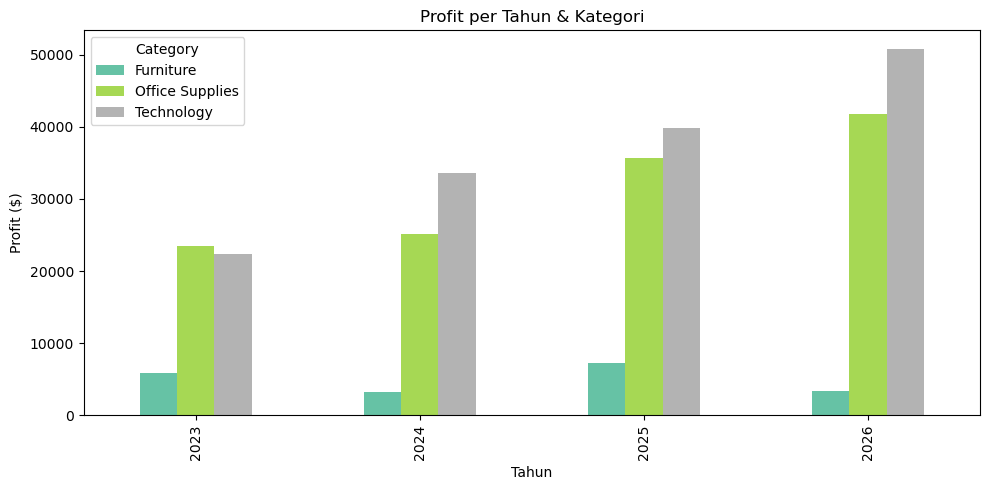

In [33]:
pivot2 = df.pivot_table(
    values="Profit",
    index="Year",
    columns="Category",
    aggfunc="sum"
)

pivot2.plot(kind = "bar", figsize=(10,5), colormap="Set2")
plt.title("Profit per Tahun & Kategori")
plt.xlabel("Tahun")
plt.ylabel("Profit ($)")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

## 5. Top 10 Sub-categpry by Profit

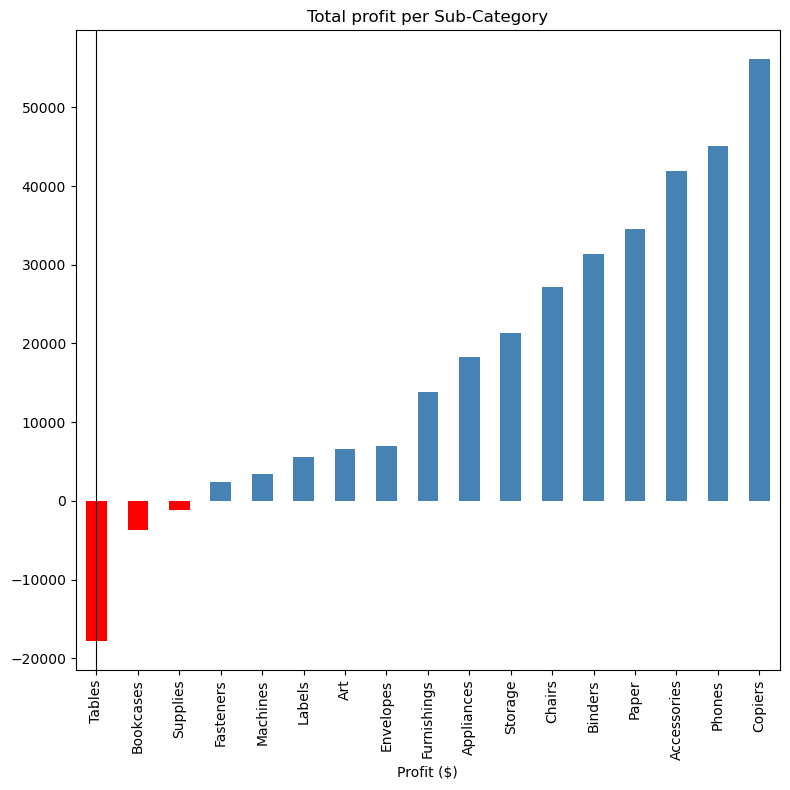

In [41]:
top_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 8))
top_subcat.plot(kind="bar", color=["red" if x < 0 else "steelblue" for x in top_subcat])
plt.title("Total profit per Sub-Category")
plt.xlabel("Profit ($)")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()